# Environment Setup and Dependencies

This cell installs necessary libraries and imports modules for data handling, deep learning, and visualization.

In [1]:
# Install required libraries
!pip install -q torch torchvision matplotlib scikit-learn seaborn

In [2]:
import os
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Download and Extraction
This cell downloads the EuroSAT RGB dataset. It extracts the files into a local directory for processing.

In [3]:
import ssl

# Define URL and directory paths
DATA_URL = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
ZIP_FILE = "EuroSAT.zip"
EXTRACT_DIR = "EuroSAT_Data"

# Create an unverified SSL context explicitly
ssl_context = ssl._create_unverified_context()

# Download the dataset if it does not exist
if not os.path.exists(ZIP_FILE):
    print("Downloading EuroSAT dataset... This may take a few minutes.")
    try:
        # Use urlopen to download the data with the unverified context
        with urllib.request.urlopen(DATA_URL, context=ssl_context) as response:
            with open(ZIP_FILE, 'wb') as out_file:
                out_file.write(response.read())
        print("Download complete.")
    except Exception as e:
        print(f"An error occurred during download: {e}")
        print("Attempting with urllib.request.urlretrieve without context (might still fail due to SSL).")
        urllib.request.urlretrieve(DATA_URL, ZIP_FILE) # Fallback, though likely to fail if context was the issue

# Extract the zip file
if not os.path.exists(EXTRACT_DIR):
    print("Extracting files...")
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete.")

# Define the path to the images
DATA_DIR = os.path.join(EXTRACT_DIR, "2750")
print(f"Dataset ready at: {DATA_DIR}")
print("Classes found:", os.listdir(DATA_DIR))

Dataset ready at: EuroSAT_Data/2750
Classes found: ['Pasture', 'HerbaceousVegetation', 'AnnualCrop', 'Forest', 'Residential', 'River', 'Industrial', 'Highway', 'SeaLake', 'PermanentCrop']


Displaying one sample image per class:


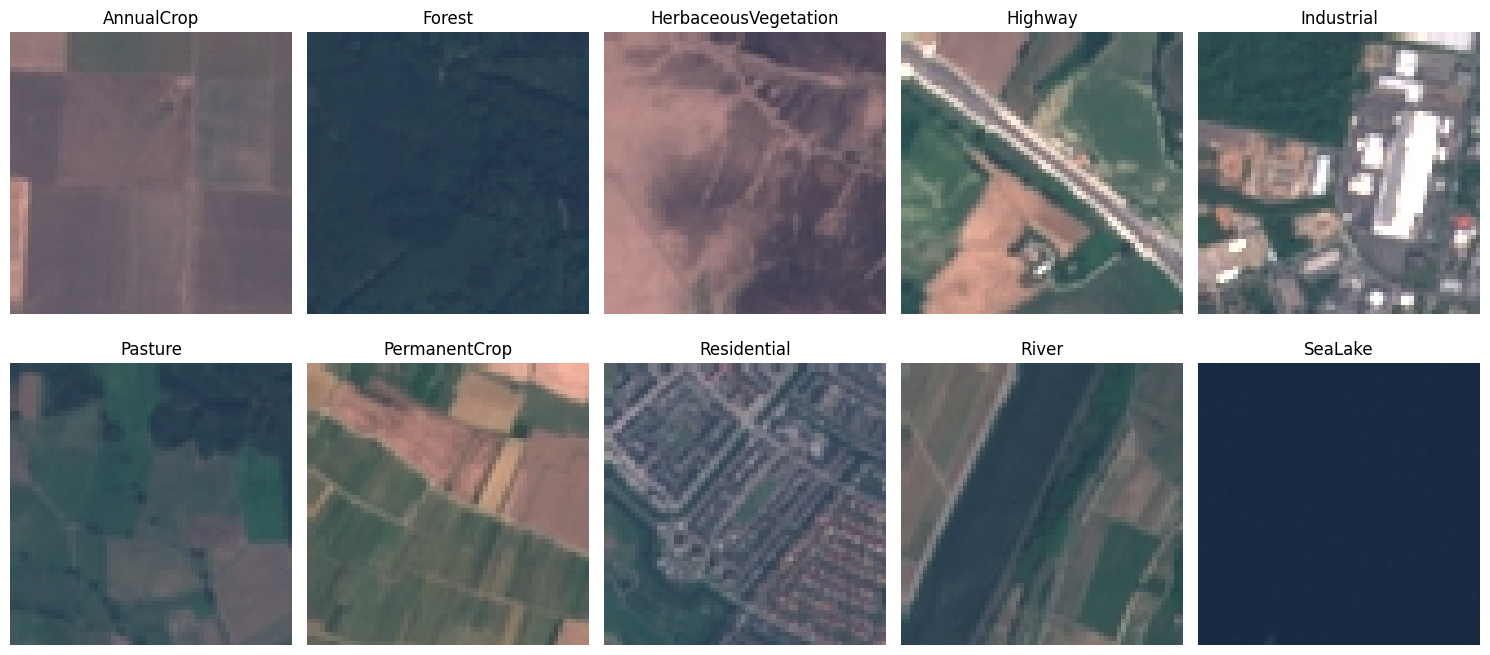

In [4]:
from torchvision.datasets import ImageFolder

print("Displaying one sample image per class:")

# Load dataset using ImageFolder (moved here to fix NameError)
# DATA_DIR is assumed to be defined by a previous cell (vYYS7I4PpZ4g)
full_dataset = ImageFolder(root=DATA_DIR)
# Get class names from the full dataset
class_names_eda = full_dataset.classes

# Dictionary to store one image per class
sample_images = {}

# Iterate through the dataset to find one image for each class
for i in range(len(full_dataset)):
    image, label = full_dataset[i]
    class_name = class_names_eda[label]
    if class_name not in sample_images:
        sample_images[class_name] = image
    if len(sample_images) == len(class_names_eda):
        break

# Plotting the sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i, (class_name, image) in enumerate(sample_images.items()):
    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_14759/955606200.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_class_names, y=sorted_counts, palette="viridis")


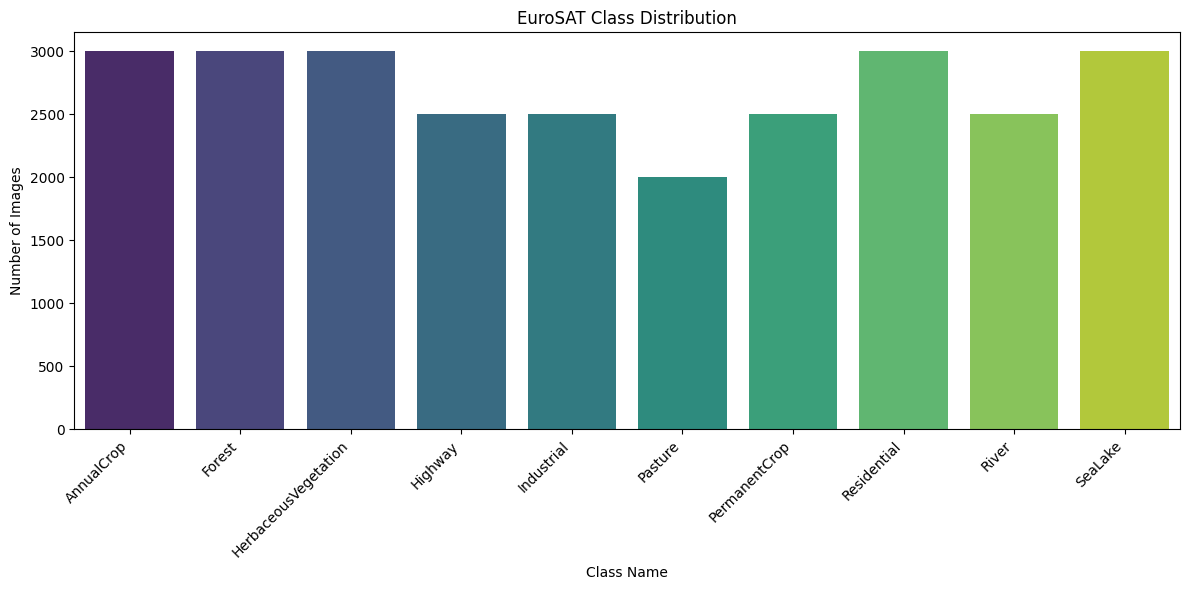

Class distribution:
  AnnualCrop: 3000
  Forest: 3000
  HerbaceousVegetation: 3000
  Highway: 2500
  Industrial: 2500
  Pasture: 2000
  PermanentCrop: 2500
  Residential: 3000
  River: 2500
  SeaLake: 3000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class distribution
class_counts = {}
for _, label in full_dataset:
    class_name = class_names_eda[label]  # Changed from class_names to class_names_eda
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Sort classes by name for consistent plotting
sorted_class_names = sorted(class_counts.keys())
sorted_counts = [class_counts[name] for name in sorted_class_names]

# Plot the class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_class_names, y=sorted_counts, palette="viridis")
plt.title('EuroSAT Class Distribution')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Class distribution:")
for name, count in zip(sorted_class_names, sorted_counts):
    print(f"  {name}: {count}")

# Data Transformation and DataLoaders
This cell defines image transformations. It resizes images, applies data augmentation to prevent overfitting, and splits data into training, validation, and testing sets.

In [6]:
# Define image transformations
# Standardize image sizes and normalize using ImageNet stats
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Load dataset using ImageFolder
full_dataset = ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes

# Define dataset split sizes (80% train, 10% validation, 10% test)
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_base, val_base, test_base = random_split(full_dataset, [train_size, val_size, test_size])

# Apply specific transformations to each split
class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.base_dataset[index]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.base_dataset)

train_dataset = TransformedDataset(train_base, data_transforms['train'])
val_dataset = TransformedDataset(val_base, data_transforms['val_test'])
test_dataset = TransformedDataset(test_base, data_transforms['val_test'])

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 21600
Validation samples: 2700
Test samples: 2700


#CNN Model Architecture
This cell builds a transfer learning model using ResNet18. It modifies the final layer to output predictions for the 10 land cover classes.

In [7]:
# Load pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early convolutional layers to preserve low-level features
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final residual block for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

# Modify the final fully connected layer for 10 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

# Move model to GPU if available
model = model.to(device)

print("Model architecture loaded and modified successfully.")

Model architecture loaded and modified successfully.


#Model Training and Validation Functions
This cell defines the training loop. It optimizes cross-entropy loss and tracks performance across epochs.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

#Model Training Execution
This cell executes the training process over a specified number of epochs. It logs accuracy and loss statistics.

In [9]:
EPOCHS = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting training loop...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

print("Training finished.")

Starting training loop...
Epoch 1/5:
  Train Loss: 0.3082 | Train Acc: 90.01%
  Val Loss:   0.1585 | Val Acc:   94.70%
Epoch 2/5:
  Train Loss: 0.1923 | Train Acc: 93.54%
  Val Loss:   0.1495 | Val Acc:   95.22%
Epoch 3/5:
  Train Loss: 0.1546 | Train Acc: 94.89%
  Val Loss:   0.1484 | Val Acc:   95.04%
Epoch 4/5:
  Train Loss: 0.1379 | Train Acc: 95.32%
  Val Loss:   0.1390 | Val Acc:   95.48%
Epoch 5/5:
  Train Loss: 0.1192 | Train Acc: 95.97%
  Val Loss:   0.1424 | Val Acc:   95.30%
Training finished.


#Performance Evaluation
This cell evaluates the model on the unseen test set. It prints a detailed classification report and displays a confusion matrix heatmap.


Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.96      0.96       300
              Forest       0.97      0.99      0.98       297
HerbaceousVegetation       0.91      0.93      0.92       302
             Highway       0.93      0.94      0.93       269
          Industrial       0.99      0.95      0.97       257
             Pasture       0.89      0.96      0.92       187
       PermanentCrop       0.94      0.89      0.91       254
         Residential       0.97      0.98      0.98       314
               River       0.96      0.92      0.94       245
             SeaLake       0.99      1.00      0.99       275

            accuracy                           0.95      2700
           macro avg       0.95      0.95      0.95      2700
        weighted avg       0.95      0.95      0.95      2700



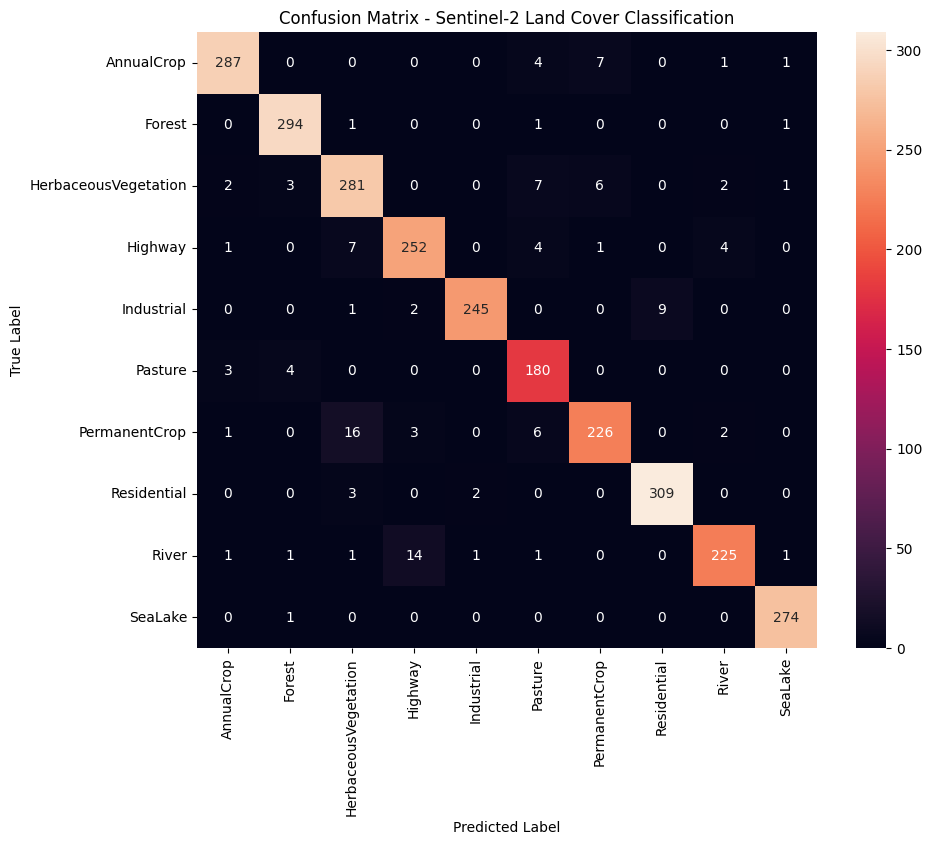

In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate metrics
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Sentinel-2 Land Cover Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()